original features: 30
-----------------------------------
components needed:
  80% variance -> 5 components
  90% variance -> 7 components
  95% variance -> 10 components
  99% variance -> 17 components


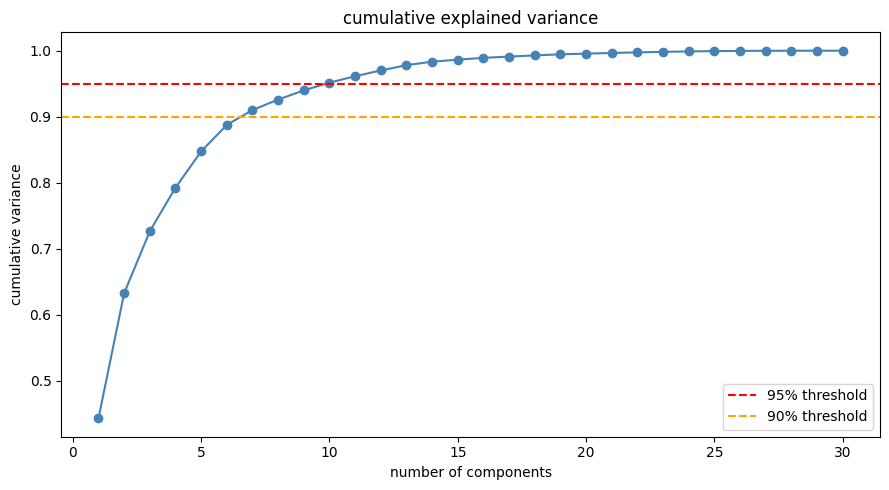

In [2]:
from sklearn.decomposition import PCA
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

cancer = load_breast_cancer()
x = cancer.data

print("original features:", x.shape[1])

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

pca = PCA()
pca.fit(x_scaled)

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

print("-" * 35)
print("components needed:")
for threshold in [0.80, 0.90, 0.95, 0.99]:
    n = np.argmax(cumulative_variance >= threshold) + 1
    print(f"  {int(threshold*100)}% variance -> {n} components")

plt.figure(figsize=(9, 5))
plt.plot(range(1, len(cumulative_variance) + 1),
         cumulative_variance, marker="o", color="steelblue")
plt.axhline(y=0.95, color="red", linestyle="--", label="95% threshold")
plt.axhline(y=0.90, color="orange", linestyle="--", label="90% threshold")
plt.title("cumulative explained variance")
plt.xlabel("number of components")
plt.ylabel("cumulative variance")
plt.legend()
plt.tight_layout()
plt.show()